# Public Wolffia Native Program Scoring

## tl;dr

This notebook scores public `Wolffia australiana` Waus8730 cells using the Wolffia-native marker-program candidate table. It complements the Arabidopsis-transfer labels by asking whether ambiguous Wolffia clusters show reproducible native marker programs.

Executed result summary:

- 11,084 public Wolffia cells were scored across four runs.
- All 103 candidate marker genes in the current table were present in the Waus8730 expression matrix.
- Dawn-group cells showed higher mean scores for photosynthesis/light harvesting, carbon fixation/assimilation, and chloroplast gene expression/plastid translation.
- Dusk-group cells showed higher mean scores for nutrient transport, RNA-binding/regulatory, and stress/chaperone response.
- These scores are exploratory Wolffia-native program scores, not final cell-type labels.

The notebook is designed to be rerun after the four public STARsolo count matrices and model-application outputs are available on external project storage.

## Context & Methods

The Arabidopsis-transfer model is intentionally conservative, so many Wolffia cells remain `ambiguous`. That is useful scientifically, but it means we need a second layer that looks at Wolffia-native marker genes directly.

This notebook uses `data/metadata/wolffia_native_program_marker_candidates.csv` as a marker prior list. For each candidate program, it computes the mean normalized/log1p expression of the marker genes present in the Waus8730 matrix. The scores are exploratory program activity scores, not final cell-type labels.

### Key assumptions

- The normalized `.h5ad` files use Waus8730 gene IDs as `var_names`.
- Marker-program candidates are annotation-guided and require manual review.
- Dawn/dusk labels are sample-level metadata from the public run grouping, not experimental validation of circadian state.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
sc.settings.verbosity = 2

# nbconvert may execute from the notebooks/ folder. Walk upward until the repo marker is found.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name == "notebooks" or not (REPO_ROOT / "data" / "metadata").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate repository root")
    REPO_ROOT = REPO_ROOT.parent

SSD_ROOT = Path("/Volumes/LaCie/wolffia_single_cell")

PROCESSED_DIR = SSD_ROOT / "results" / "processed_h5ad"
MODEL_DIR = SSD_ROOT / "results" / "model_application"
COMBINED_DIR = SSD_ROOT / "results" / "combined_public_wolffia"

MARKER_TABLE = REPO_ROOT / "data" / "metadata" / "wolffia_native_program_marker_candidates.csv"
OUT_DIR = REPO_ROOT / "figures" / "wolffia_native_program_scores"
OUT_META = REPO_ROOT / "data" / "metadata"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_META.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    "SRR29417746": {"timepoint": "dawn", "replicate": "dawn_1"},
    "SRR29417745": {"timepoint": "dawn", "replicate": "dawn_2"},
    "SRR29417744": {"timepoint": "dusk", "replicate": "dusk_1"},
    "SRR29417743": {"timepoint": "dusk", "replicate": "dusk_2"},
}
RUNS = list(RUN_METADATA)

print("Repository:", REPO_ROOT)
print("External data root:", SSD_ROOT)
print("Runs:", ", ".join(RUNS))

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
External data root: /Volumes/LaCie/wolffia_single_cell
Runs: SRR29417746, SRR29417745, SRR29417744, SRR29417743


## Data

Load the marker-program candidate table, the four normalized public Wolffia matrices, and the existing leaf/root transfer predictions.

In [2]:
marker_candidates = pd.read_csv(MARKER_TABLE)
marker_candidates.head()

,native_program_id,native_program_name,waus8730_gene_id,preferred_name,source_leiden_clusters,best_marker_rank,max_marker_score,evidence_level,annotation_summary,candidate_rationale,review_status
0,carbon_fixation_assimilation,Carbon fixation / assimilation,Waus8730.v1.chr13.g040080,-,0;11;12,1,30.9583,high,fructose-bisphosphate aldolase,"Marker annotation supports carbon fixation, Ca...",candidate_for_manual_review
1,carbon_fixation_assimilation,Carbon fixation / assimilation,Waus8730.v1.chr9.g148620,RCA,6;8,1,33.4219,high,Ribulose bisphosphate carboxylase oxygenase ac...,"Marker annotation supports carbon fixation, Ca...",candidate_for_manual_review
2,carbon_fixation_assimilation,Carbon fixation / assimilation,Waus8730.v1.chr11.g023520,-,0;4;11,3,39.6595,high,RuBisCO catalyzes two reactions the carboxylat...,"Marker annotation supports carbon fixation, Ca...",candidate_for_manual_review
3,carbon_fixation_assimilation,Carbon fixation / assimilation,Waus8730.v1.chr14.g043590,-,6;8,3,28.9053,high,fructose-bisphosphate aldolase,"Marker annotation supports carbon fixation, Ca...",candidate_for_manual_review
4,carbon_fixation_assimilation,Carbon fixation / assimilation,Waus8730.v1.chr20.g087750,-,9,3,36.4510,high,Bifunctional monodehydroascorbate reductase an...,"Marker annotation supports carbon fixation, Ca...",candidate_for_manual_review


In [3]:
program_counts = (
    marker_candidates
    .groupby(["native_program_id", "native_program_name"], as_index=False)
    .agg(candidate_genes=("waus8730_gene_id", "nunique"))
    .sort_values("candidate_genes", ascending=False)
)
program_counts

,native_program_id,native_program_name,candidate_genes
3,lipid_surface_cell_wall,Lipid / surface / cell-wall biology,20
5,photosynthesis_light_harvesting,Photosynthesis / light harvesting,20
0,carbon_fixation_assimilation,Carbon fixation / assimilation,16
1,chloroplast_gene_expression,Chloroplast gene expression / plastid translation,14
7,stress_chaperone_response,Stress / chaperone response,10
2,ion_water_balance,Ion / water balance,9
4,nutrient_transport,Nutrient transport,6
8,unknown_high_marker,Unknown high-ranking marker,5
6,rna_binding_regulatory,RNA-binding / regulatory,3


In [4]:
adatas = []
for run in RUNS:
    h5ad_path = PROCESSED_DIR / f"{run}_normalized_log1p.h5ad"
    pred_path = MODEL_DIR / run / "combined_leaf_root_predictions.csv"
    if not h5ad_path.exists():
        raise FileNotFoundError(h5ad_path)
    if not pred_path.exists():
        raise FileNotFoundError(pred_path)

    sample = ad.read_h5ad(h5ad_path)
    sample.obs_names = [f"{run}_{bc}" for bc in sample.obs_names.astype(str)]
    sample.obs["run"] = run
    sample.obs["timepoint"] = RUN_METADATA[run]["timepoint"]
    sample.obs["replicate"] = RUN_METADATA[run]["replicate"]

    predictions = pd.read_csv(pred_path)
    predictions.index = [f"{run}_{bc}" for bc in predictions["cell_id"].astype(str)]
    keep_cols = ["final_label", "final_interpretation_status", "leaf_accepted", "root_accepted"]
    sample.obs = sample.obs.join(predictions[keep_cols], how="left")
    adatas.append(sample)

combined = ad.concat(adatas, join="inner", merge="same", label="run_from_concat", keys=RUNS)
combined.obs["final_label"] = combined.obs["final_label"].fillna("missing_prediction")
combined.obs["final_interpretation_status"] = combined.obs["final_interpretation_status"].fillna("missing_prediction")

print(combined)
print("Cells:", combined.n_obs)
print("Genes:", combined.n_vars)
combined.obs[["run", "timepoint", "replicate", "final_label", "final_interpretation_status"]].head()

AnnData object with n_obs × n_vars = 11084 × 15080
    obs: 'run', 'timepoint', 'replicate', 'final_label', 'final_interpretation_status', 'leaf_accepted', 'root_accepted', 'run_from_concat'
    var: 'feature_type'
Cells: 11084
Genes: 15080


,run,timepoint,replicate,final_label,final_interpretation_status
SRR29417746_AAACCCACAAGTCCCG,SRR29417746,dawn,dawn_1,ambiguous,both_models_ambiguous
SRR29417746_AAACCCAGTATTTCGG,SRR29417746,dawn,dawn_1,ambiguous,both_models_ambiguous
SRR29417746_AAACGAAAGCAAACAT,SRR29417746,dawn,dawn_1,ambiguous,both_models_ambiguous
SRR29417746_AAACGAATCAGTCACA,SRR29417746,dawn,dawn_1,photosynthetic_or_assimilation,primary_leaf_supported_root_ambiguous
SRR29417746_AAACGCTAGGCAATGC,SRR29417746,dawn,dawn_1,ambiguous,both_models_ambiguous


## Score native marker programs

For each candidate program, the score is the average normalized/log1p expression of the marker genes present in the combined Waus8730 matrix. Scores are also z-scaled within each program for easier visualization across programs.

In [5]:
def mean_expression_score(adata, genes):
    present = [g for g in genes if g in adata.var_names]
    if not present:
        return np.full(adata.n_obs, np.nan), present
    X = adata[:, present].X
    if hasattr(X, "toarray"):
        values = np.asarray(X.mean(axis=1)).ravel()
    else:
        values = np.asarray(X).mean(axis=1)
    return values, present

program_gene_sets = {}
coverage_rows = []

for program_id, sub in marker_candidates.groupby("native_program_id"):
    program_name = sub["native_program_name"].iloc[0]
    genes = sorted(sub["waus8730_gene_id"].dropna().unique())
    scores, present = mean_expression_score(combined, genes)
    score_col = f"score_{program_id}"
    z_col = f"zscore_{program_id}"
    combined.obs[score_col] = scores
    if np.isfinite(scores).sum() > 1 and np.nanstd(scores) > 0:
        combined.obs[z_col] = (scores - np.nanmean(scores)) / np.nanstd(scores)
    else:
        combined.obs[z_col] = np.nan
    program_gene_sets[program_id] = present
    coverage_rows.append({
        "native_program_id": program_id,
        "native_program_name": program_name,
        "candidate_genes": len(genes),
        "genes_present_in_matrix": len(present),
        "coverage_fraction": len(present) / len(genes) if genes else np.nan,
    })

program_coverage = pd.DataFrame(coverage_rows).sort_values("candidate_genes", ascending=False)
coverage_path = OUT_META / "wolffia_native_program_score_gene_coverage.csv"
program_coverage.to_csv(coverage_path, index=False)
print("Wrote:", coverage_path)
program_coverage

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_native_program_score_gene_coverage.csv


,native_program_id,native_program_name,candidate_genes,genes_present_in_matrix,coverage_fraction
3,lipid_surface_cell_wall,Lipid / surface / cell-wall biology,20,20,1.0
5,photosynthesis_light_harvesting,Photosynthesis / light harvesting,20,20,1.0
0,carbon_fixation_assimilation,Carbon fixation / assimilation,16,16,1.0
1,chloroplast_gene_expression,Chloroplast gene expression / plastid translation,14,14,1.0
7,stress_chaperone_response,Stress / chaperone response,10,10,1.0
2,ion_water_balance,Ion / water balance,9,9,1.0
4,nutrient_transport,Nutrient transport,6,6,1.0
8,unknown_high_marker,Unknown high-ranking marker,5,5,1.0
6,rna_binding_regulatory,RNA-binding / regulatory,3,3,1.0


## Build combined UMAP

The UMAP is computed from the combined normalized Waus8730 matrix. It is used only for visualization of native program scores and transfer labels.

In [6]:
sc.pp.highly_variable_genes(combined, n_top_genes=3000, flavor="seurat")
sc.pp.pca(combined, n_comps=40, use_highly_variable=True, svd_solver="arpack")
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=30)
sc.tl.umap(combined, random_state=7)
sc.tl.leiden(combined, resolution=0.8, key_added="leiden_native_program", random_state=7)

print("Leiden clusters:", combined.obs["leiden_native_program"].nunique())
combined.obs[["run", "timepoint", "final_label", "leiden_native_program"]].head()

extracting highly variable genes


    finished (0:00:00)


computing PCA


    with n_comps=40


    finished (0:00:01)


...

    finished (0:00:04)


running Leiden clustering


    finished (0:00:00)


Leiden clusters: 16


,run,timepoint,final_label,leiden_native_program
SRR29417746_AAACCCACAAGTCCCG,SRR29417746,dawn,ambiguous,11
SRR29417746_AAACCCAGTATTTCGG,SRR29417746,dawn,ambiguous,13
SRR29417746_AAACGAAAGCAAACAT,SRR29417746,dawn,ambiguous,12
SRR29417746_AAACGAATCAGTCACA,SRR29417746,dawn,photosynthetic_or_assimilation,2
SRR29417746_AAACGCTAGGCAATGC,SRR29417746,dawn,ambiguous,5


## Results: program score summaries

The summary table reports mean native-program scores by run, dawn/dusk group, and transfer label. These values are useful for checking whether a candidate program is reproducible across runs or enriched in a particular transfer-label group.

In [7]:
score_cols = [c for c in combined.obs.columns if c.startswith("score_")]
zscore_cols = [c for c in combined.obs.columns if c.startswith("zscore_")]
program_name_lookup = marker_candidates.drop_duplicates("native_program_id").set_index("native_program_id")["native_program_name"].to_dict()

summary_rows = []
for group_cols in [["run"], ["timepoint"], ["final_label"], ["leiden_native_program"], ["timepoint", "final_label"]]:
    grouped = combined.obs.groupby(group_cols, observed=True)
    for group_key, group_df in grouped:
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        base = dict(zip(group_cols, group_key))
        for col in score_cols:
            program_id = col.replace("score_", "")
            summary_rows.append({
                "grouping": "+".join(group_cols),
                **base,
                "native_program_id": program_id,
                "native_program_name": program_name_lookup.get(program_id, program_id),
                "n_cells": len(group_df),
                "mean_score": group_df[col].mean(),
                "median_score": group_df[col].median(),
            })

program_score_summary = pd.DataFrame(summary_rows)
summary_path = OUT_META / "wolffia_native_program_score_summary.csv"
program_score_summary.to_csv(summary_path, index=False)
print("Wrote:", summary_path)
program_score_summary.head(12)

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_native_program_score_summary.csv


,grouping,run,native_program_id,native_program_name,n_cells,mean_score,median_score,timepoint,final_label,leiden_native_program
0,run,SRR29417743,carbon_fixation_assimilation,Carbon fixation / assimilation,2666,3.295175,3.367120,NaN,NaN,NaN
1,run,SRR29417743,chloroplast_gene_expression,Chloroplast gene expression / plastid translation,2666,1.678121,1.492792,NaN,NaN,NaN
2,run,SRR29417743,ion_water_balance,Ion / water balance,2666,1.228455,1.142290,NaN,NaN,NaN
3,run,SRR29417743,lipid_surface_cell_wall,Lipid / surface / cell-wall biology,2666,0.733216,0.580122,NaN,NaN,NaN
4,run,SRR29417743,nutrient_transport,Nutrient transport,2666,0.919278,0.682717,NaN,NaN,NaN
5,run,SRR29417743,photosynthesis_light_harvesting,Photosynthesis / light harvesting,2666,2.738991,2.738097,NaN,NaN,NaN
6,run,SRR29417743,rna_binding_regulatory,RNA-binding / regulatory,2666,2.987074,3.151434,NaN,NaN,NaN
7,run,SRR29417743,stress_chaperone_response,Stress / chaperone response,2666,1.304781,1.304133,NaN,NaN,NaN
8,run,SRR29417743,unknown_high_marker,Unknown high-ranking marker,2666,1.183049,1.146288,NaN,NaN,NaN
9,run,SRR29417744,carbon_fixation_assimilation,Carbon fixation / assimilation,2886,3.292325,3.359777,NaN,NaN,NaN


Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_native_program_scores/native_program_score_heatmaps.png


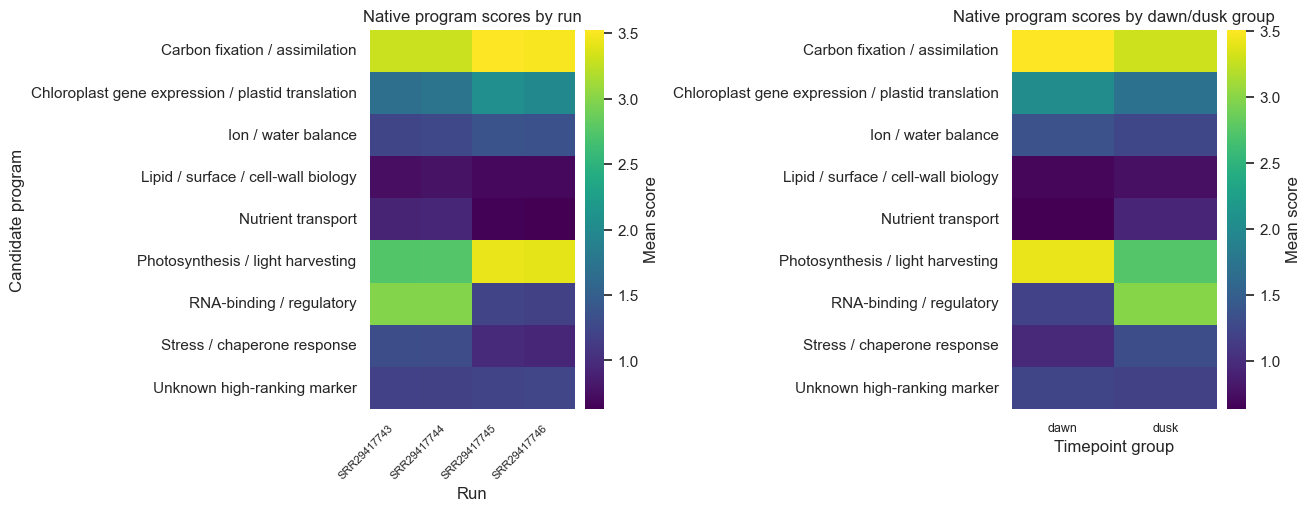

In [8]:
run_heatmap = (
    program_score_summary
    .query("grouping == 'run'")
    .pivot(index="native_program_name", columns="run", values="mean_score")
)

timepoint_heatmap = (
    program_score_summary
    .query("grouping == 'timepoint'")
    .pivot(index="native_program_name", columns="timepoint", values="mean_score")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.heatmap(run_heatmap, cmap="viridis", ax=axes[0], cbar_kws={"label": "Mean score"})
axes[0].set_title("Native program scores by run")
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Candidate program")
axes[0].tick_params(axis="x", labelrotation=45, labelsize=8)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

sns.heatmap(timepoint_heatmap, cmap="viridis", ax=axes[1], cbar_kws={"label": "Mean score"})
axes[1].set_title("Native program scores by dawn/dusk group")
axes[1].set_xlabel("Timepoint group")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelrotation=0, labelsize=9)

fig_path = OUT_DIR / "native_program_score_heatmaps.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Results: UMAP overlays

These panels show where candidate Wolffia-native programs are high in the combined expression landscape.

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_native_program_scores/native_program_score_umap_grid.png


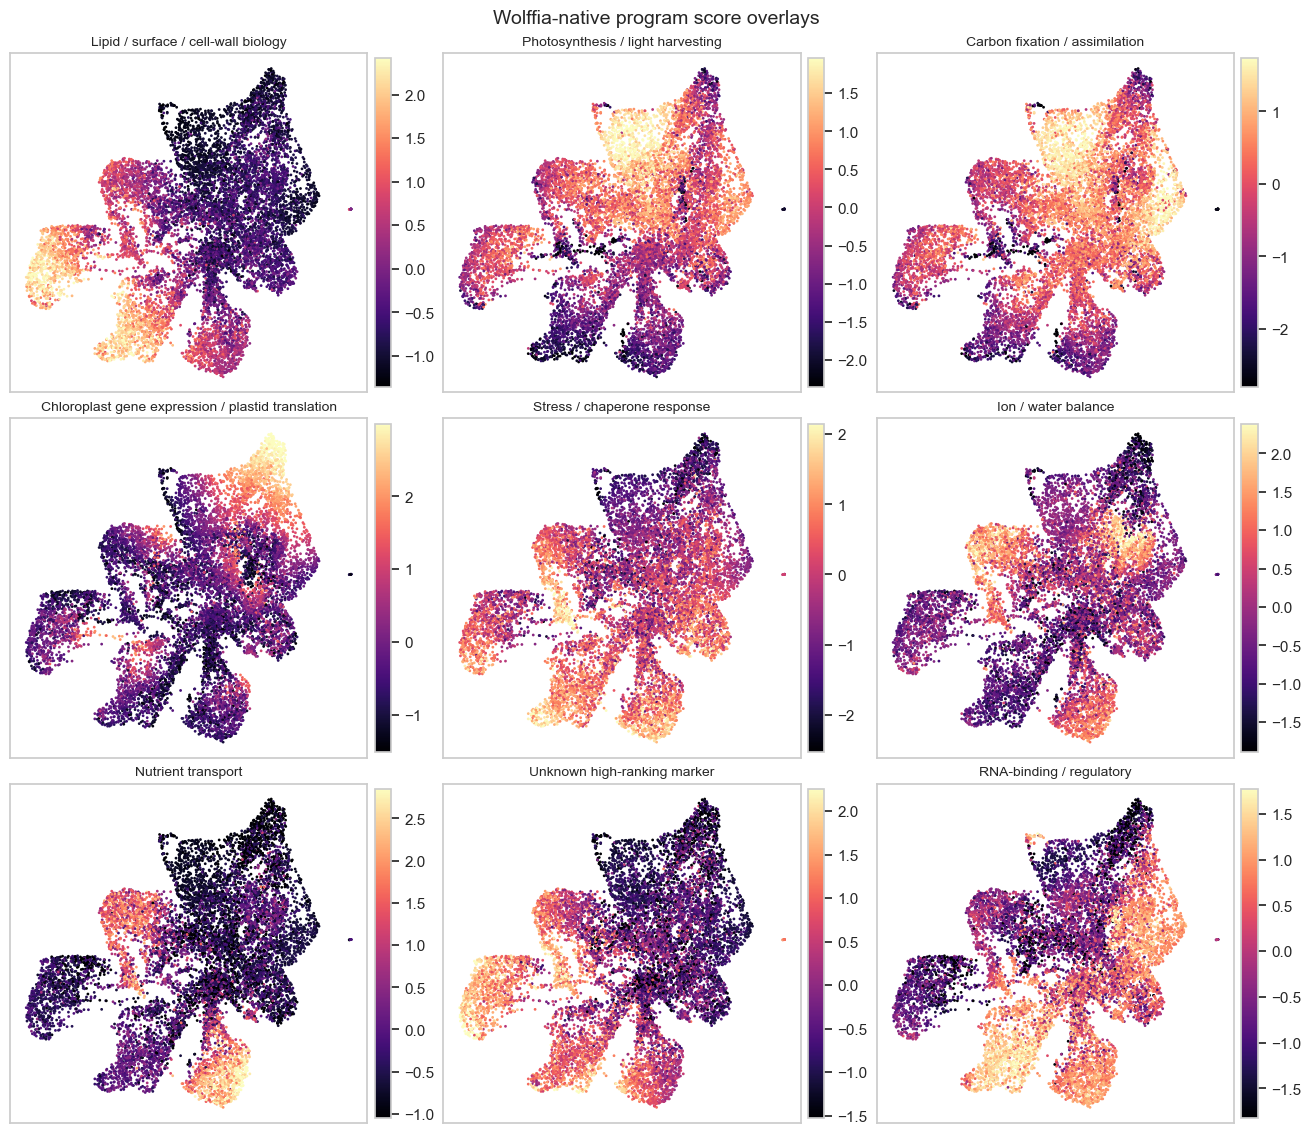

In [9]:
program_order = (
    program_coverage
    .sort_values(["genes_present_in_matrix", "candidate_genes"], ascending=False)["native_program_id"]
    .tolist()
)

plot_cols = [f"zscore_{pid}" for pid in program_order]
plot_titles = [program_name_lookup.get(pid, pid) for pid in program_order]

fig, axes = plt.subplots(3, 3, figsize=(13, 11), constrained_layout=True)
axes = axes.ravel()
coords = combined.obsm["X_umap"]
for ax, col, title in zip(axes, plot_cols, plot_titles):
    values = combined.obs[col].astype(float).to_numpy()
    vmax = np.nanpercentile(values, 99)
    vmin = np.nanpercentile(values, 1)
    sca = ax.scatter(coords[:, 0], coords[:, 1], c=values, s=4, cmap="magma", vmin=vmin, vmax=vmax, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(sca, ax=ax, fraction=0.046, pad=0.02)
for ax in axes[len(plot_cols):]:
    ax.axis("off")
fig.suptitle("Wolffia-native program score overlays", y=1.02, fontsize=14)
fig_path = OUT_DIR / "native_program_score_umap_grid.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_native_program_scores/combined_umap_context_panels.png


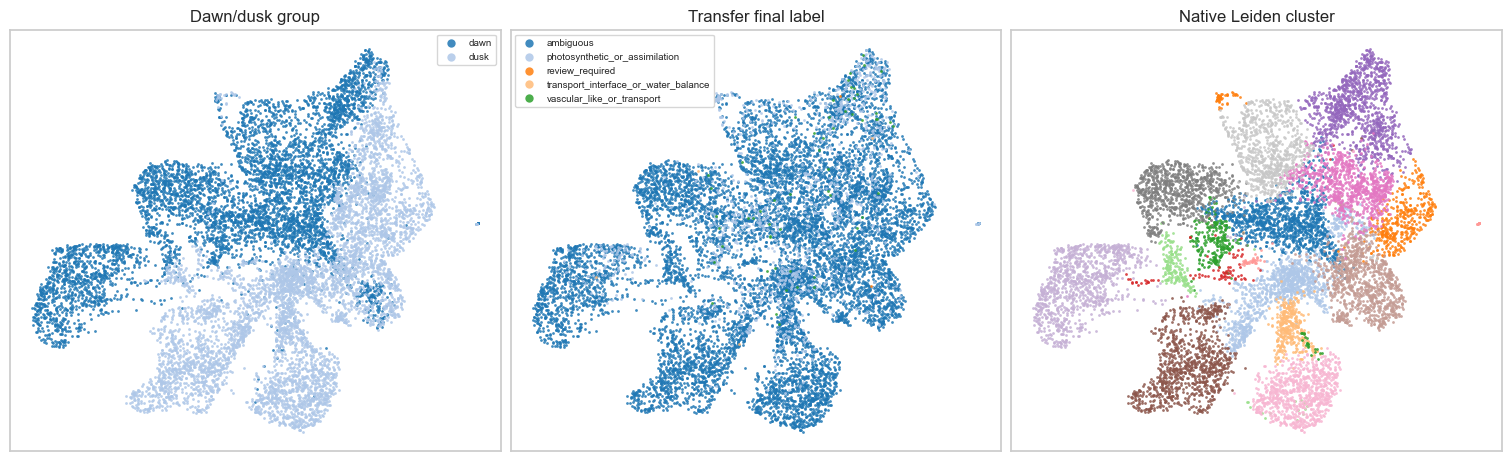

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, color_col, title in [
    (axes[0], "timepoint", "Dawn/dusk group"),
    (axes[1], "final_label", "Transfer final label"),
    (axes[2], "leiden_native_program", "Native Leiden cluster"),
]:
    categories = combined.obs[color_col].astype(str)
    palette = dict(zip(sorted(categories.unique()), sns.color_palette("tab20", n_colors=categories.nunique())))
    for cat, color in palette.items():
        mask = categories == cat
        ax.scatter(coords[mask, 0], coords[mask, 1], s=4, label=cat, color=color, linewidths=0, alpha=0.85)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    if categories.nunique() <= 12:
        ax.legend(markerscale=3, fontsize=7, loc="best", frameon=True)

fig_path = OUT_DIR / "combined_umap_context_panels.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Results: program scores by transfer label

This view asks whether the Wolffia-native program scores agree with the conservative Arabidopsis-transfer labels. A strong photosynthesis score in photosynthetic-labeled cells is a useful sanity check. High scores in ambiguous cells are also important because they may reveal Wolffia-native states that the Arabidopsis model does not confidently label.

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_native_program_scores/native_program_scores_by_transfer_label.png


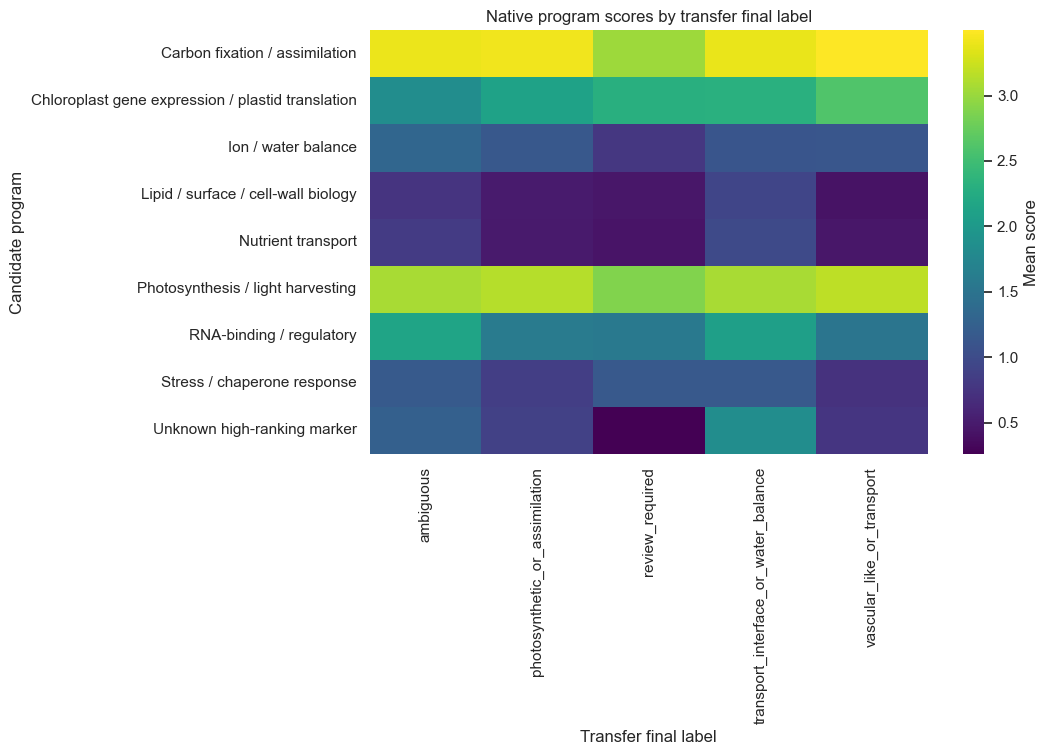

In [11]:
label_heatmap = (
    program_score_summary
    .query("grouping == 'final_label'")
    .pivot(index="native_program_name", columns="final_label", values="mean_score")
)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(label_heatmap, cmap="viridis", ax=ax, cbar_kws={"label": "Mean score"})
ax.set_title("Native program scores by transfer final label")
ax.set_xlabel("Transfer final label")
ax.set_ylabel("Candidate program")
fig_path = OUT_DIR / "native_program_scores_by_transfer_label.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Takeaways

The exact values below are generated from the executed notebook outputs.

In [12]:
# Compact, data-backed takeaways for the top of the notebook and repo notes.
photosyn = "photosynthesis_light_harvesting"
carbon = "carbon_fixation_assimilation"
stress = "stress_chaperone_response"
ion = "ion_water_balance"

def timepoint_delta(program_id):
    sub = program_score_summary.query("grouping == 'timepoint' and native_program_id == @program_id")
    vals = dict(zip(sub["timepoint"], sub["mean_score"]))
    return vals.get("dawn", np.nan), vals.get("dusk", np.nan), vals.get("dawn", np.nan) - vals.get("dusk", np.nan)

for pid in [photosyn, carbon, stress, ion]:
    if pid in program_name_lookup:
        dawn, dusk, delta = timepoint_delta(pid)
        print(f"{program_name_lookup[pid]}: dawn={dawn:.4f}, dusk={dusk:.4f}, dawn-minus-dusk={delta:.4f}")

accepted = combined.obs["final_label"].ne("ambiguous").mean()
print(f"Non-ambiguous transfer-label fraction across combined cells: {accepted:.3%}")
print(f"Total cells scored: {combined.n_obs:,}")

Photosynthesis / light harvesting: dawn=3.4179, dusk=2.7473, dawn-minus-dusk=0.6706
Carbon fixation / assimilation: dawn=3.5113, dusk=3.2937, dawn-minus-dusk=0.2176
Stress / chaperone response: dawn=0.9574, dusk=1.2996, dawn-minus-dusk=-0.3422
Ion / water balance: dawn=1.3569, dusk=1.2434, dawn-minus-dusk=0.1135
Non-ambiguous transfer-label fraction across combined cells: 10.285%
Total cells scored: 11,084


## Interpretation notes

- The native marker scores should be used as quantitative program scores, not as one-cell-one-label annotations.
- Ambiguous transfer-model cells can still have strong native marker-program scores. That is one of the main reasons to keep this layer.
- For future salt-stress data, these same marker programs can be scored per cell and then compared between control and treated samples.